<a href="https://colab.research.google.com/github/DifferentiableUniverseInitiative/JaxPM/blob/main/notebooks/01-Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [2]:
# Installing JaxPM
# !pip install --quiet --upgrade jax
# !pip install --quiet jaxpm

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
if 'debug' not in globals():
    debug = True
    import debugpy
    debugpy.listen(('127.0.0.1', 5678))

In [5]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc

from jax.experimental.ode import odeint

from jaxpm.painting import cic_paint
from jaxpm.pm import linear_field, lpt, make_avera_ode, make_t_ode

import matplotlib.pyplot as plt

/home/dobos/project/covera/jax_cosmo/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [6]:
mesh_shape = [128, 128, 128]
box_size = [128., 128., 128.]
# box_size = [64., 64., 64.]
# box_size = [32., 32., 32.]

k = jnp.logspace(-4, 1, 128)
pk = jc.power.linear_matter_power(jc.Planck15(), k)
pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)
initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(10))
particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

/datascope/slurm/miniconda3/envs/dobos-jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [7]:
a = 0.1
# snapshots = jnp.array([a, 0.5, 0.7, 0.9, 1.0, 1.05, 1.1])
snapshots = jnp.linspace(a, 1.1, 100)

@jax.jit
def run_simulation(): # omega_c, sigma8):
    cosmo = jc.EdS()

    # Evolve the simulation forward
    res = odeint(make_t_ode(), [(2/3) * a**(3/2)], snapshots, cosmo,
                 rtol=1e-8,
                 atol=1e-8)

    # Return the simulation volume at requested timesteps
    return res[0]

In [8]:
t = run_simulation()

a: 0.10000000149011612, t: [Array(0.02108185, dtype=float32)]
a: 0.10066666454076767, t: [Array(0.02129267, dtype=float32)]
a: 0.10183312743902206, t: [Array(0.02166154, dtype=float32)]
a: 0.10274969041347504, t: [Array(0.02195733, dtype=float32)]
a: 0.1073324978351593, t: [Array(0.02344259, dtype=float32)]
a: 0.10814721882343292, t: [Array(0.02371, dtype=float32)]
a: 0.10916562378406525, t: [Array(0.02404569, dtype=float32)]
a: 0.10916562378406525, t: [Array(0.02404571, dtype=float32)]
a: 0.11597716808319092, t: [Array(0.02629626, dtype=float32)]
a: 0.11938294768333435, t: [Array(0.02749933, dtype=float32)]
a: 0.13641181588172913, t: [Array(0.03358757, dtype=float32)]
a: 0.1394391655921936, t: [Array(0.03471026, dtype=float32)]
a: 0.1432233601808548, t: [Array(0.03613271, dtype=float32)]
a: 0.1432233601808548, t: [Array(0.03613512, dtype=float32)]
a: 0.15490542352199554, t: [Array(0.04055618, dtype=float32)]
a: 0.16074645519256592, t: [Array(0.04296558, dtype=float32)]
a: 0.1899516284

In [9]:
snapshots, t

(Array([0.1       , 0.11010101, 0.12020202, 0.13030304, 0.14040405,
        0.15050505, 0.16060606, 0.17070708, 0.18080808, 0.19090909,
        0.20101011, 0.21111111, 0.22121212, 0.23131314, 0.24141414,
        0.25151515, 0.26161617, 0.2717172 , 0.28181818, 0.2919192 ,
        0.3020202 , 0.3121212 , 0.32222223, 0.33232325, 0.34242427,
        0.35252526, 0.36262628, 0.37272727, 0.3828283 , 0.39292932,
        0.4030303 , 0.41313133, 0.42323235, 0.43333334, 0.44343436,
        0.45353538, 0.46363637, 0.4737374 , 0.48383838, 0.4939394 ,
        0.5040404 , 0.51414144, 0.5242424 , 0.5343434 , 0.54444444,
        0.55454546, 0.5646465 , 0.57474744, 0.5848485 , 0.5949495 ,
        0.60505056, 0.6151515 , 0.62525254, 0.6353535 , 0.6454546 ,
        0.65555555, 0.66565657, 0.6757576 , 0.6858586 , 0.69595957,
        0.70606065, 0.7161616 , 0.7262626 , 0.73636365, 0.74646467,
        0.7565657 , 0.76666665, 0.77676773, 0.7868687 , 0.7969698 ,
        0.80707073, 0.81717175, 0.8272727 , 0.83

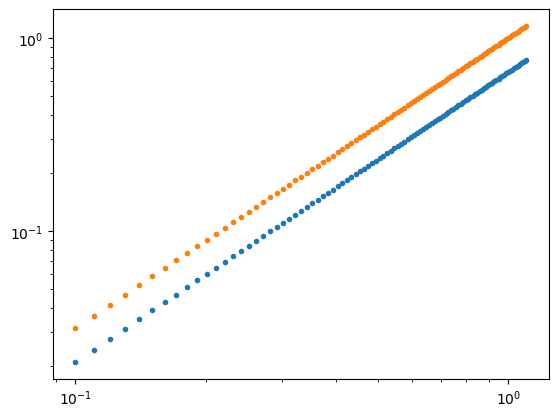

In [10]:
plt.loglog(snapshots, t, '.')
plt.loglog(snapshots, snapshots**(3/2), '.')

In [69]:
# Initial a where the simulation starts
a = 0.1
a_avera = 0.1

# These must be given in the variable we integrate over, i.e. in standard cosmology
# snapshots = jnp.array([0.1, 0.5, 1.0, 1.3, 1.5])
snapshots = jnp.array([a, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05])
# snapshots = jnp.array([1.1, 2.5, 5, 7, 10.0])

@jax.jit
def run_simulation(): # omega_c, sigma8):
    # Create a small function to generate the matter power spectrum
    # k = jnp.logspace(-4, 1, 128)
    # pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    # pk = jc.power.linear_matter_power(jc.EdS(), k)
    # pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)

    # Create initial conditions and particles
    # initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(10))
    # particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

    # Initial displacement
    cosmo = jc.Planck15()

    # LPT takes the intial conditions at a=1, z=0 according to the cosmology
    # and transfers it back to the given a
    # H_0 of cosmo is used to calculate the initial conditions
    dx, p, f = lpt(cosmo, initial_conditions, particles, a=a)

    # Evolve the simulation forward
    # H_0 of cosmo is not used in what follows
    cosmo = jc.EdS()
    res = odeint(make_avera_ode(mesh_shape),
                 [
                     particles + dx,
                     p,
                     a_avera,
                     
                     # time
                     0.03777494,
                     # (2/3) * a**(3/2)
                ],
                 snapshots, snapshots[0], cosmo,
                 rtol=1e-8,
                 atol=1e-8)

    # Return the simulation volume at requested timesteps
    return initial_conditions,  particles + dx , res[0], res[2], res[3]

In [70]:
initial_conditions , lpt_particles , ode_particles, a_avg, t = run_simulation()

a, a_avera: 0.10000000149011612 0.10000000149011612 2097152
a, a_avera: 0.10557779669761658 0.10557782649993896 2097152
a, a_avera: 0.1003643199801445 0.1003643199801445 2097152
a, a_avera: 0.1005464717745781 0.10054647922515869 2097152
a, a_avera: 0.10145726799964905 0.10145732015371323 2097152
a, a_avera: 0.1016191840171814 0.10161926597356796 2097152
a, a_avera: 0.10182157903909683 0.10182168334722519 2097152
a, a_avera: 0.10182157903909683 0.1018216535449028 2097152
a, a_avera: 0.1024799793958664 0.10248010605573654 2097152
a, a_avera: 0.10280917584896088 0.1028093546628952 2097152
a, a_avera: 0.10445518046617508 0.10445563495159149 2097152
a, a_avera: 0.10474780201911926 0.10474831610918045 2097152
a, a_avera: 0.10511358082294464 0.1051141768693924 2097152
a, a_avera: 0.10511358082294464 0.10511418431997299 2097152
a, a_avera: 0.1060071587562561 0.10600797832012177 2097152
a, a_avera: 0.10645394772291183 0.10645491629838943 2097152
a, a_avera: 0.1086878851056099 0.1086896657943725

In [71]:
snapshots, a_avg, t

(Array([0.1 , 0.2 , 0.3 , 0.4 , 0.5 , 0.7 , 0.9 , 1.  , 1.01, 1.02, 1.03,
        1.04, 1.05], dtype=float32),
 Array([0.1       , 0.20037822, 0.30224833, 0.4068209 , 0.5152701 ,
        0.74758416, 1.0041262 , 1.1418846 , 1.156003  , 1.1701844 ,
        1.1844294 , 1.1987364 , 1.2131056 ], dtype=float32),
 Array([0.03777494, 0.07632159, 0.12623762, 0.1853479 , 0.25239542,
        0.40713435, 0.58590287, 0.68335915, 0.6933842 , 0.70345896,
        0.71358407, 0.72375804, 0.7339799 ], dtype=float32))

In [72]:
from scipy.interpolate import interp1d
interp1d(a_avg, t)(1.0)

array(0.58302758)

In [78]:
# Using astropy, calculate the look back time as a function of the scale factor of LambdaCDM Planck15
from astropy.cosmology import Planck15
from astropy import units as u
import numpy as np
a_vals = np.linspace(0.1, 1.0, 100)
t_vals = Planck15.age(1/a_vals - 1).to(u.Gyr)
H0 = Planck15.H0
H0_inv_Gyr = (1 / H0).to(u.Gyr)
t_vals_H0 = (t_vals / H0_inv_Gyr).value

In [74]:
# t_vals_H0, a_vals

(0.030000000000000013, 1.0)

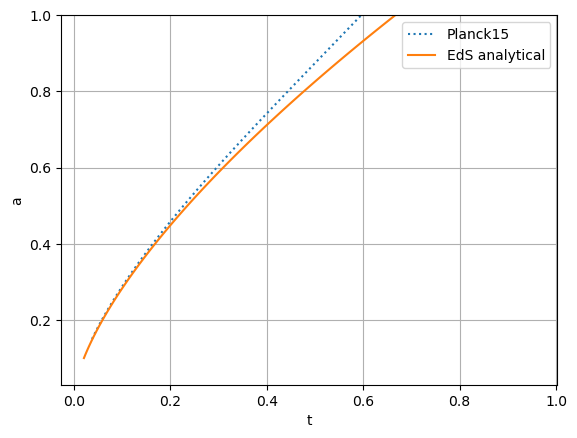

In [82]:
# plt.plot(t, a_avg, '-', label='Avera')
# plt.plot(t, snapshots, '--', label='EdS')
plt.plot(t_vals_H0, a_vals * (3/2), ':', label='Planck15')
plt.plot((2/3) * a_vals**(3/2), a_vals, label='EdS analytical')

plt.legend()
plt.grid()
plt.xlabel('t')
plt.ylabel('a')
plt.ylim(None, 1)

In [43]:
cic_paint(jnp.zeros(mesh_shape), lpt_particles).max()

Array(3.4923275, dtype=float32)

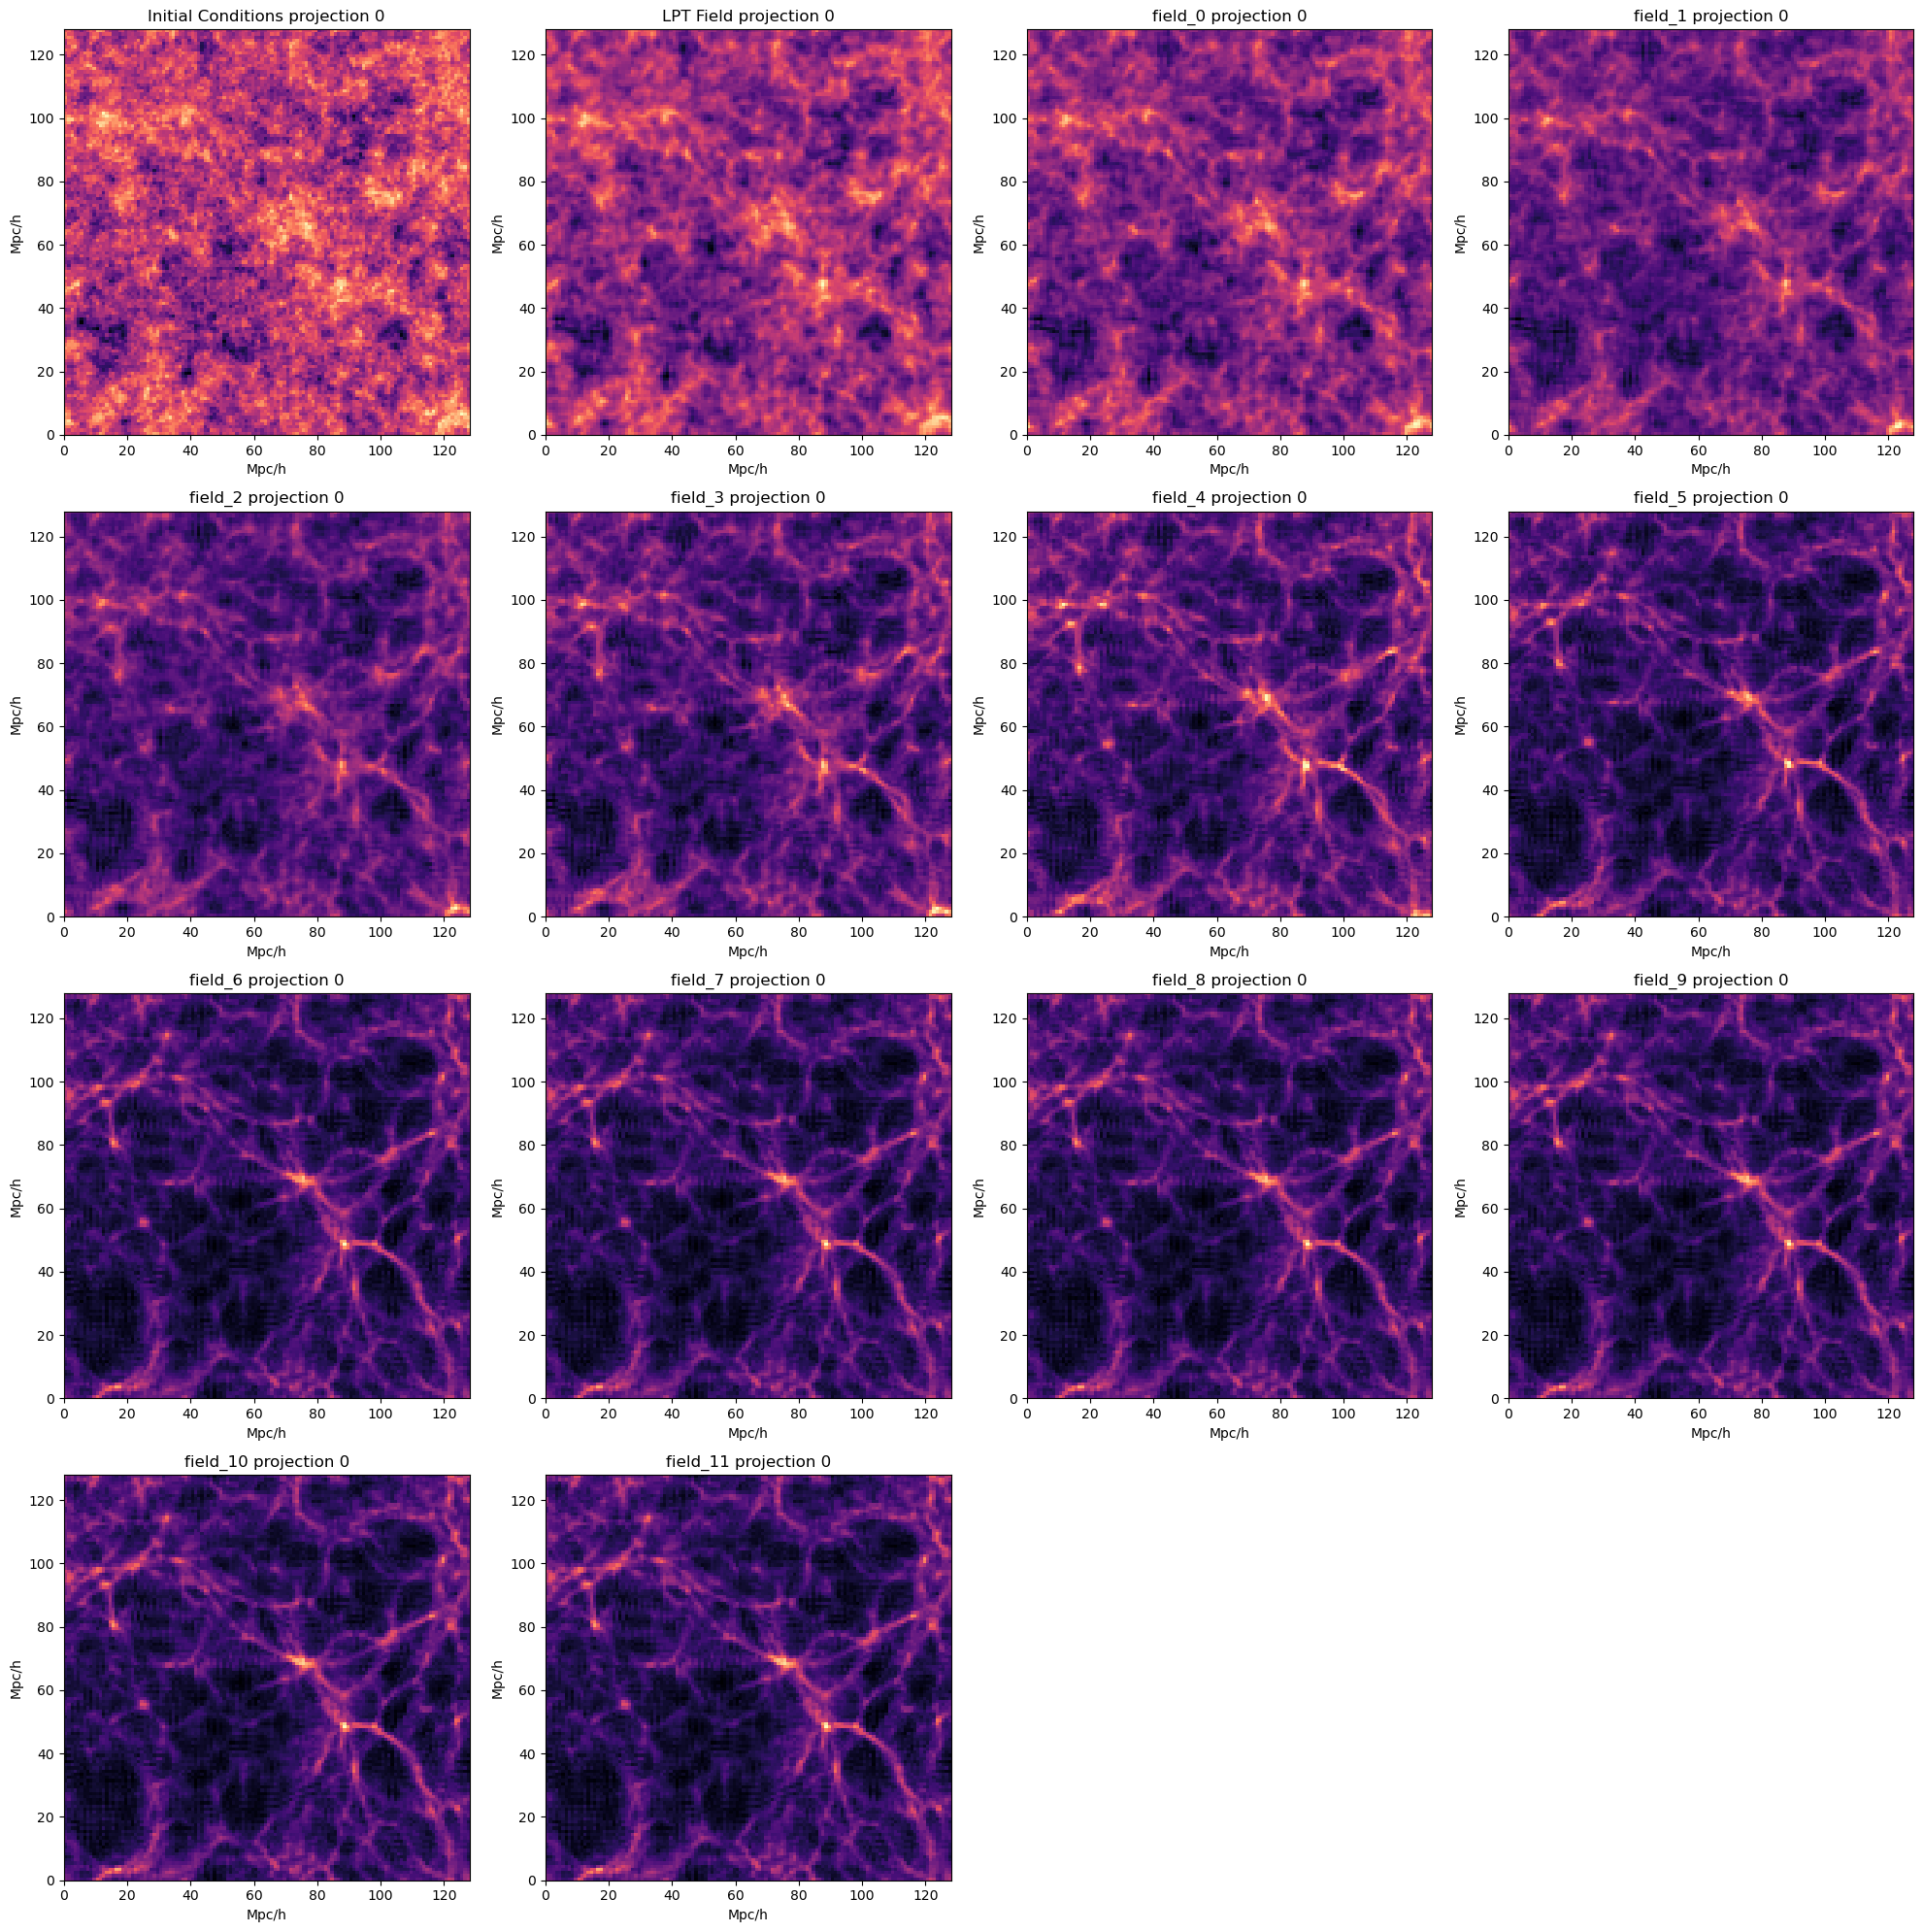

In [44]:
from jaxpm.plotting import plot_fields_single_projection

fields = {"Initial Conditions" : initial_conditions , "LPT Field" : jnp.log10(cic_paint(jnp.zeros(mesh_shape) ,lpt_particles) + 1)}
for i , field in enumerate(ode_particles[1:]):
    fields[f"field_{i}"] = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , field)+1)
plot_fields_single_projection(fields)